## Notebook 1 of 5: Data overview, gene/ontology descriptions, classical VEP

This is part of a 5-notebook split of what used to be one `simplified_notebook.ipynb`
(kept as a single-file reference at `notebooks/simplified_notebook.ipynb`):

1. [`01_overview_and_vep.ipynb`](./01_overview_and_vep.ipynb) -- setup, family-aware
   train/test split, gene/ontology descriptions, AlphaGenome reference-only overview plots,
   classical Variant Effect Prediction (VEP).
2. [`02_individual_predictions.ipynb`](./02_individual_predictions.ipynb) -- per-individual
   consensus RNA-seq, comparing two individuals, bulk prediction generation.
3. [`03_population_analysis.ipynb`](./03_population_analysis.ipynb) -- population-level
   comparison, MANE-exon restriction, single-ontology restriction, significance test.
4. [`04_modeling.ipynb`](./04_modeling.ipynb) -- trains a LogisticRegression classifier on
   MANE-exon-restricted features, a second on whole-gene-span features, and a tiny torch MLP
   on the full concatenated signal; persists all three to `notebooks/.cache/models/`.
5. [`05_evaluation.ipynb`](./05_evaluation.ipynb) -- loads the persisted models, evaluates them
   on the held-out test split, reference/variant label prediction, literature-vs-background
   variant comparison.

**This is notebook 1.** Every notebook after this one only reads from `notebooks/.cache/`
(the predictions cache built by notebook 2, `notebooks/.cache/analysis/` from notebook 3
onward, and `notebooks/.cache/models/` for notebook 5) rather than this notebook's kernel
state -- they can be run in separate sessions, in order.

This notebook is self-contained: it only reads from `notebooks/data/` and `notebooks/utils/`,
never from the rest of the `genomics` package or any external dataset mount. If
`notebooks/data/` doesn't exist yet (or you want to refresh it -- e.g. to add genes or widen
the individuals covered), run **[`prepare_data.ipynb`](./prepare_data.ipynb)** first. That
notebook builds `notebooks/data/` from the raw 1000 Genomes sources (pedigree/population CSV,
GENCODE GTF, reference FASTA, per-chromosome phased VCFs) -- it's the only place in this
workflow that needs `bcftools`/`samtools` and access to those external files.


In [59]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook is self-contained: it only reads from notebooks/data/ (bundled, small
# reference/variant slices -- see notebooks/utils/prepare_data.py for how that was built)
# and notebooks/utils/ (plain Python helpers), never from the rest of the `genomics`
# package or the external dataset mount.
REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import setup, rna_features
from utils import consensus as consensus_utils
from utils import realignment
from utils import predictions as predictions_utils
from utils import annotations as annotations_utils

# Importing the alphagenome client module itself needs no API key -- only setup.create_client()
# (below) does. Imported here so constants like `dna_client.SEQUENCE_LENGTH_500KB` are
# available without requiring the key yet.
from alphagenome.data import genome
from alphagenome.models import dna_client

ctx = setup.load_experiment(NOTEBOOK_DIR)
GENES, ONTOLOGY_TERMS, CLASS_MAP = ctx.GENES, ctx.ONTOLOGY_TERMS, ctx.CLASS_MAP
WINDOW_CENTER_SIZE = ctx.WINDOW_CENTER_SIZE
gene_rows, individuals, samples_by_class = ctx.gene_rows, ctx.individuals, ctx.samples_by_class
windows_df, gtf = ctx.windows_df, ctx.gtf
ANNOTATIONS_CACHE_DIR = ctx.ANNOTATIONS_CACHE_DIR
REFERENCE_PREDICTIONS_CACHE_DIR = ctx.REFERENCE_PREDICTIONS_CACHE_DIR

print(f"Genes ({len(GENES)})       : {GENES}")
print(f"Ontology terms    : {ONTOLOGY_TERMS}")
print(f"window_center_size: {WINDOW_CENTER_SIZE}")
print(f"class_map          : {CLASS_MAP}")
print(f"individuals loaded : {len(individuals)} ({', '.join(f'{k}: {len(v)}' for k, v in samples_by_class.items())})")

client, ORGANISM = setup.create_client()
print("AlphaGenome client ready.")


Genes (11)       : ['MC1R', 'TYRP1', 'TYR', 'SLC45A2', 'DDB1', 'EDAR', 'MFSD12', 'OCA2', 'HERC2', 'SLC24A5', 'TCHH']
Ontology terms    : ['CL:1000458', 'CL:0000346', 'CL:2000092']
window_center_size: 32768
class_map          : {'strong pigmentation': ['YRI', 'ESN', 'LWK', 'MSL', 'GWD'], 'weak pigmentation': ['FIN', 'CEU', 'GBR']}
individuals loaded : 1072 (strong pigmentation: 703, weak pigmentation: 369)
AlphaGenome client ready.


## Family-aware, population-stratified train/test split

Every individual-level analysis in this notebook series -- the two-individual comparison, the
population-level mean RNA-seq comparison, the exon-restricted comparison, the significance
test, and the classifiers -- should only ever look at a held-out **train** split, so the split
is done here, right after `individuals`/`samples_by_class` are loaded, in every notebook that
needs it. Doing it early is what actually prevents leakage: any analysis cell downstream that
used `samples_by_class` instead of `train_samples_by_class` would be peeking at data the
classifier is later evaluated on.

A plain random split isn't safe here: `notebooks/data/individuals.json` carries 1000 Genomes
`family_id`s, and 214 of the 588 families in this dataset have more than one member (698 of
1,072 individuals belong to a multi-member family). Related individuals share a lot of their
genotype, so a random split would routinely put relatives on both sides of the train/test
boundary and leak signal between them.

The split is also done **per population**, not just per class: each pigmentation class is made
up of several populations (e.g. "strong pigmentation" spans YRI/ESN/LWK/MSL/GWD), and splitting
at the class level alone could, by chance, shift one population toward train and another toward
test within the same class -- population is itself a real source of RNA-seq variation this
notebook cares about, so its mix should be preserved rather than left to chance.
`family_aware_train_test_split` (in `notebooks/utils/family_split.py`, wrapped with a fixed
`test_size`/`random_seed` by `setup.get_train_test_split` so every notebook gets the identical
split) groups by `family_id` within each population and splits whole families -- the same
grouping-then-splitting approach `genomics.core.splitting` uses elsewhere in this repo for the
genotype/variant-transformer predictors, reimplemented locally since this notebook series stays
independent of the rest of the `genomics` package.


In [60]:
train_samples_by_class, test_samples_by_class = setup.get_train_test_split(individuals, CLASS_MAP)
for class_name in samples_by_class:
    print(
        f"{class_name}: {len(samples_by_class[class_name])} total -> "
        f"{len(train_samples_by_class[class_name])} train / {len(test_samples_by_class[class_name])} test"
    )


strong pigmentation: 703 total -> 570 train / 133 test
weak pigmentation: 369 total -> 292 train / 77 test


In [61]:
def get_gene_description(gene: str) -> str | None:
    return annotations_utils.get_gene_description(gene, ANNOTATIONS_CACHE_DIR)

def ontology_label(term_id: str) -> str | None:
    return annotations_utils.get_ontology_label(term_id, ANNOTATIONS_CACHE_DIR)

windows_df


,gene,chrom,start,end,window_size
0,DDB1,chr11,61058880,61583168,524288
1,EDAR,chr2,108679778,109204066,524288
2,HERC2,chr15,27954466,28478754,524288
3,MC1R,chr16,89654403,90178691,524288
4,MFSD12,chr19,3294132,3818420,524288
5,OCA2,chr15,27664951,28189239,524288
6,SLC24A5,chr15,47869688,48393976,524288
7,SLC45A2,chr5,33702514,34226802,524288
8,TCHH,chr1,151848737,152373025,524288
9,TYR,chr11,88974674,89498962,524288


In [62]:
print("======= GENES =======")
for gene in windows_df["gene"]:
    print(f"{gene}: {get_gene_description(gene)}")

print("\n======= ONTOLOGIES =======")
for ontology in ONTOLOGY_TERMS:
    print(f"{ontology}: {ontology_label(ontology)}")


======= GENES =======
DDB1: The protein encoded by this gene is the large subunit (p127) of the heterodimeric DNA damage-binding (DDB) complex while another protein (p48) forms the small subunit. This protein complex functions in nucleotide-excision repair and binds to DNA following UV damage. Defective activity of this complex causes the repair defect in patients with xeroderma pigmentosum complementation group E (XPE) - an autosomal recessive disorder characterized by photosensitivity and early onset of carcinomas. However, it remains for mutation analysis to demonstrate whether the defect in XPE patients is in this gene or the gene encoding the small subunit. In addition, Best vitelliform mascular dystrophy is mapped to the same region as this gene on 11q, but no sequence alternations of this gene are demonstrated in Best disease patients. The protein encoded by this gene also functions as an adaptor molecule for the cullin 4 (CUL4) ubiquitin E3 ligase complex by facilitating the bi

In [63]:
from alphagenome.visualization import plot_components
from alphagenome.data import transcript as transcript_utils
from alphagenome.data import gene_annotation


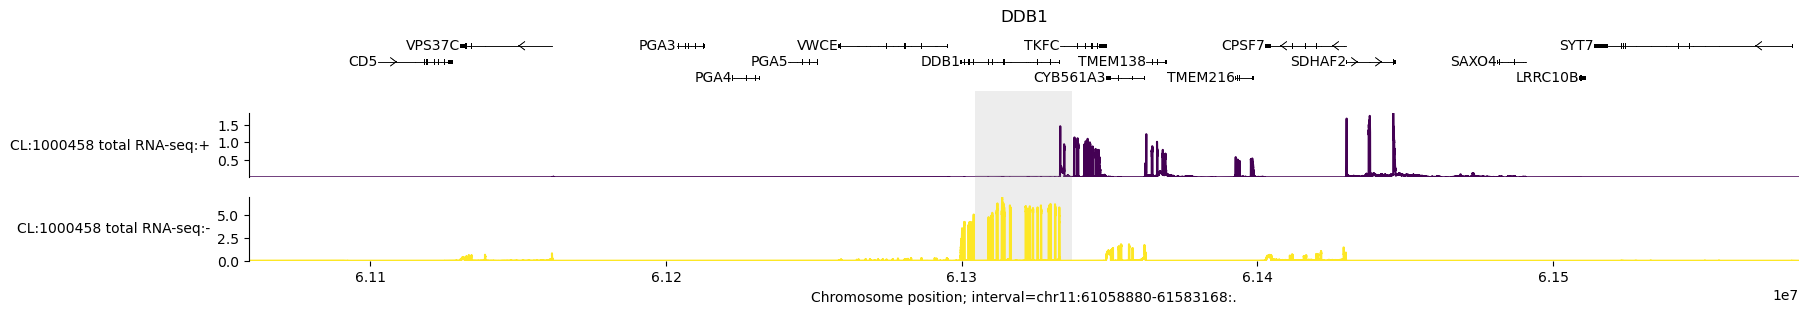

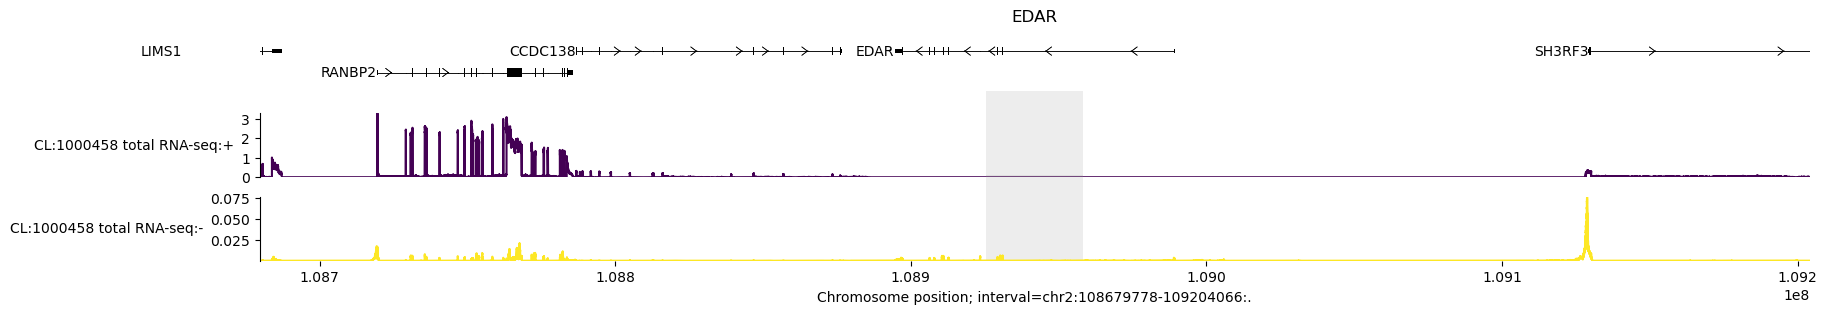

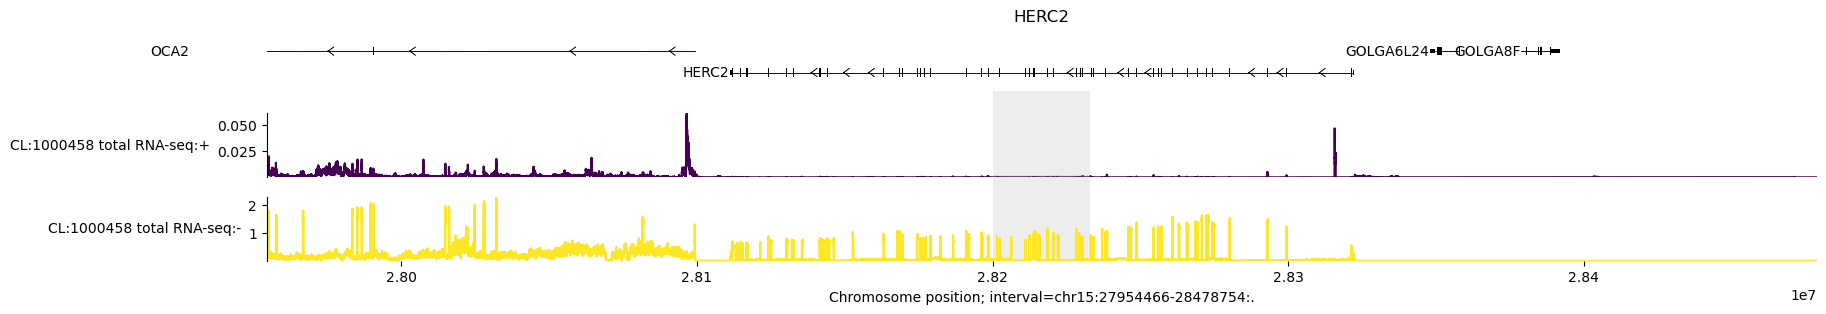

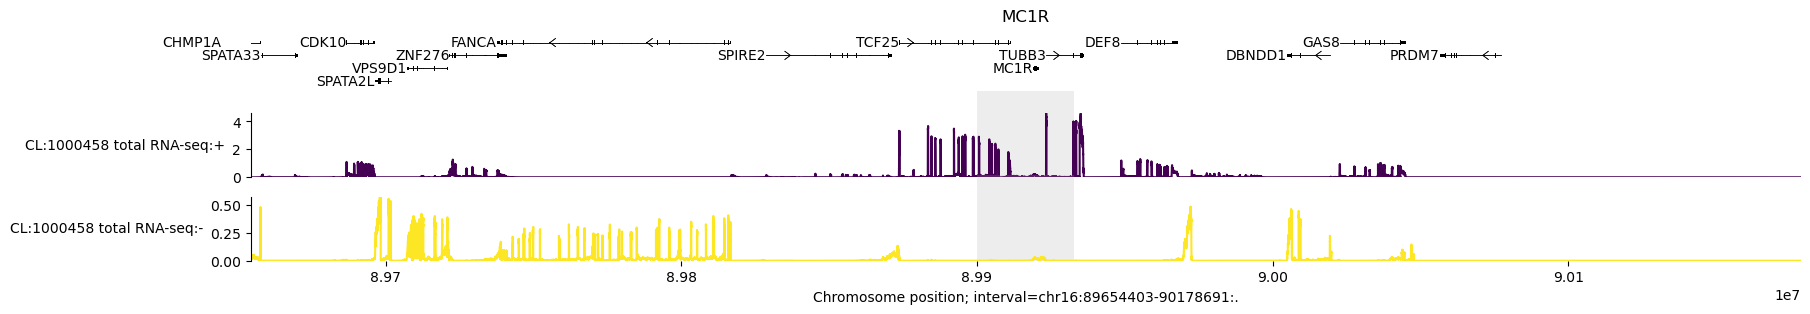

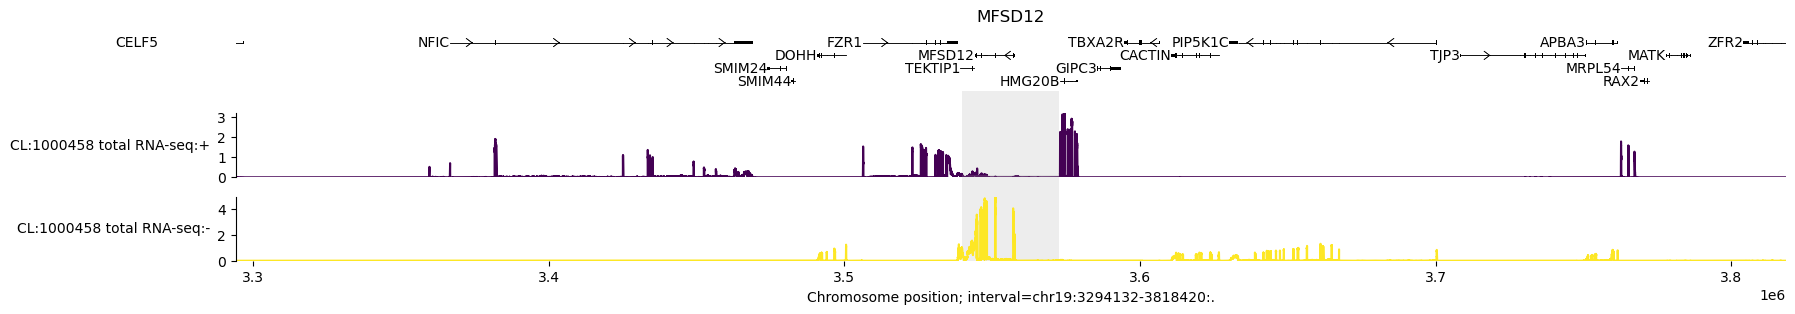

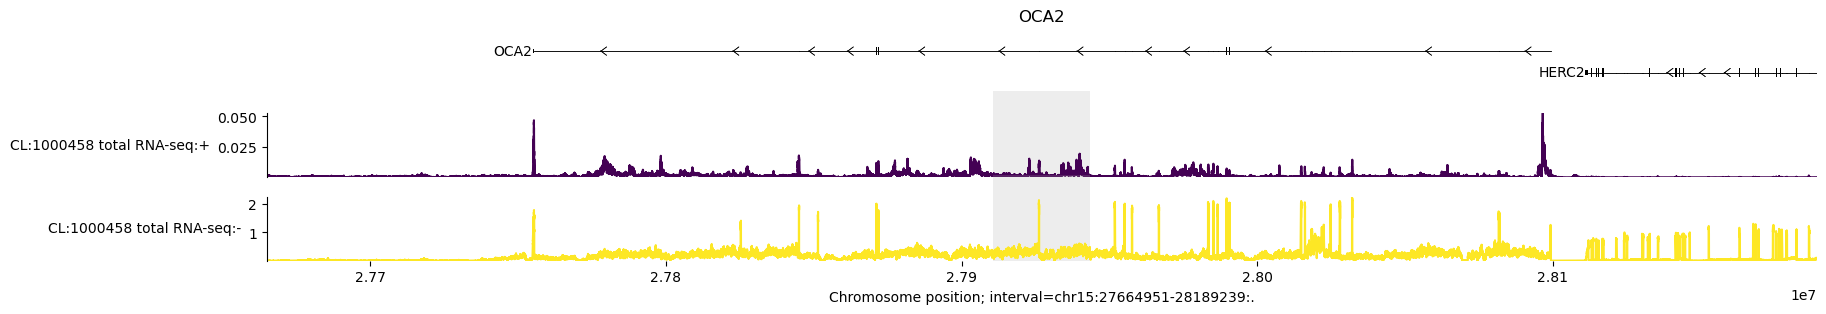

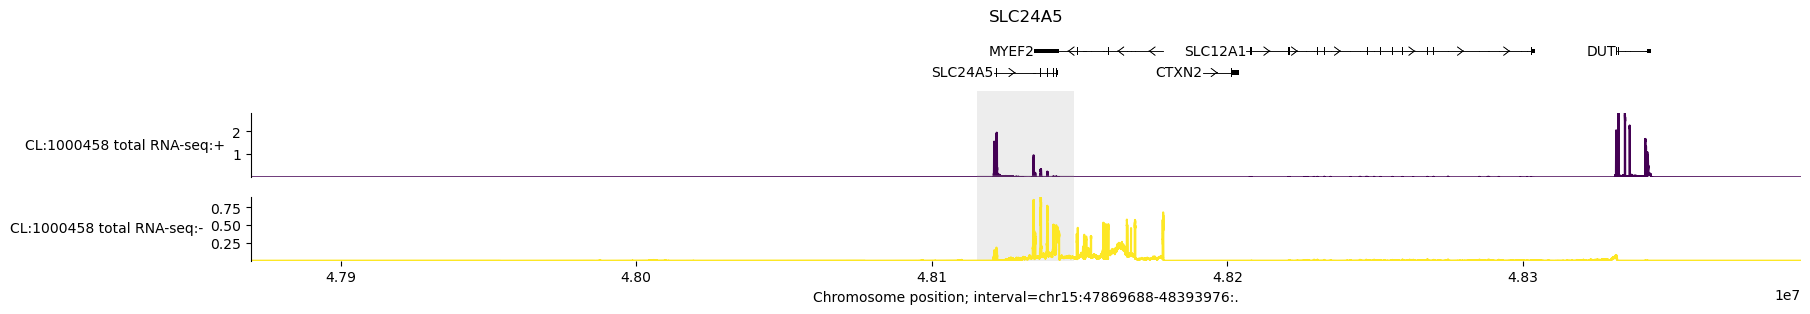

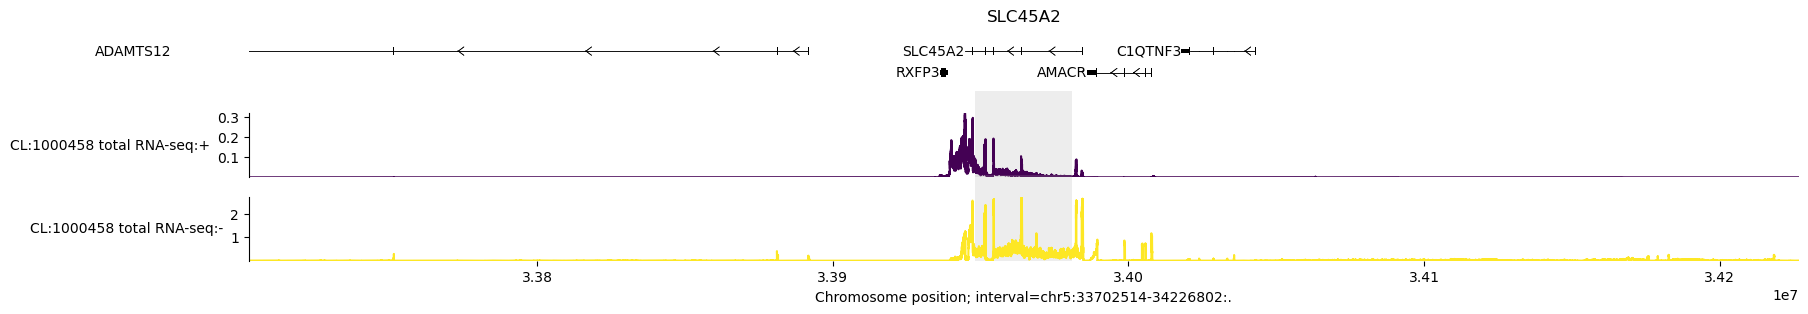

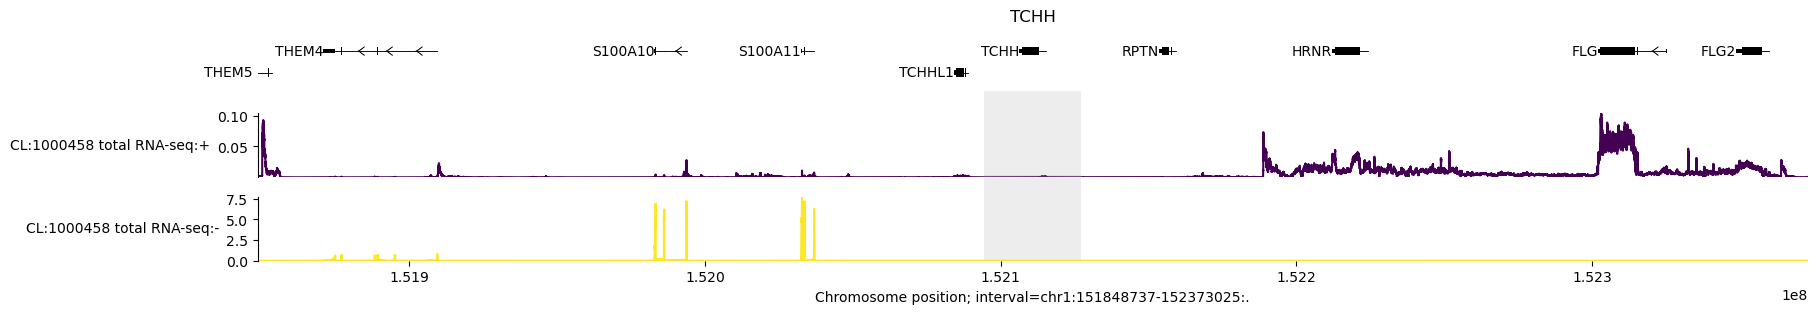

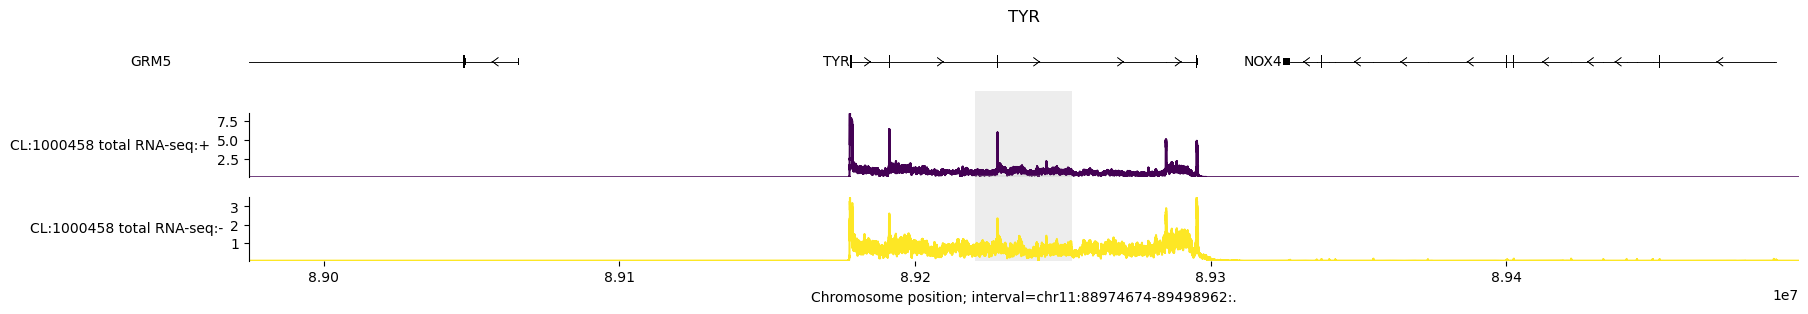

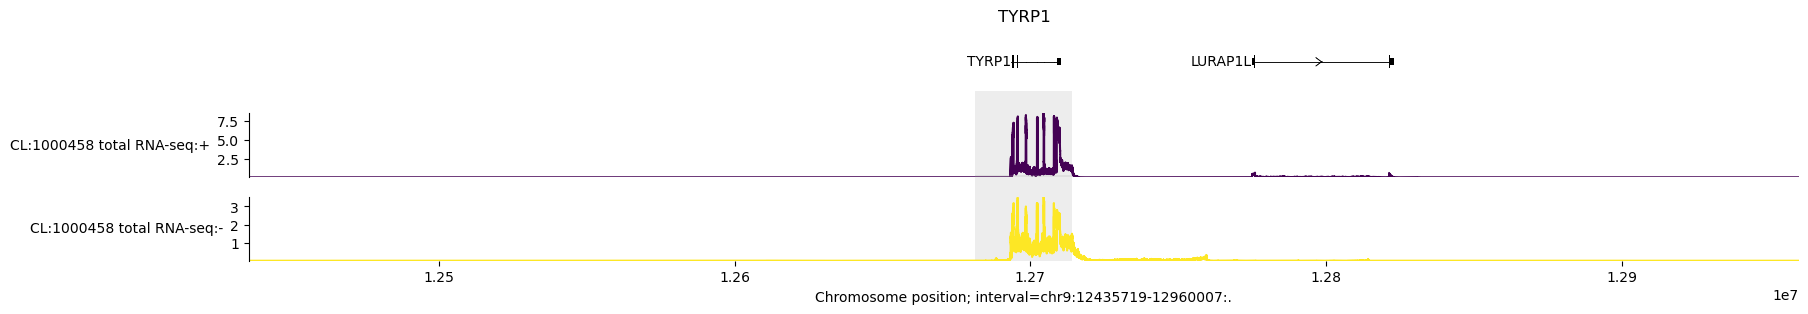

In [64]:
def plot_alphagenome_view_for_gene(
    gene: str,
    outer_window: int = dna_client.SEQUENCE_LENGTH_500KB,
    inner_window: int = 32768,
    filter_protein_coding = True,
    filter_mane_select_transcript = True,
):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]

    interval = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(outer_window)
    interval_32k = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(inner_window)

    gtf_transcripts = gtf
    if filter_protein_coding:
        gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
    if filter_mane_select_transcript:
        gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
    transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)
    transcripts = transcript_extractor.extract(interval)

    # Cached: this is a reference-only (no individual/haplotype) prediction, deterministic
    # for a given gene/interval/ontology, so a top-to-bottom notebook re-run reuses the
    # cache under notebooks/.cache/reference_predictions/ instead of re-spending API calls.
    rna_seq = predictions_utils.predict_reference_interval(
        client,
        gene=gene,
        interval=interval,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=[ONTOLOGY_TERMS[0]],
        cache_dir=REFERENCE_PREDICTIONS_CACHE_DIR,
    )

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.Tracks(rna_seq),
        ],
        annotations=[
            plot_components.IntervalAnnotation(
                intervals=[interval_32k]
            ),
        ],
        interval=interval,
        title=gene,
    )

    plt.show()      # Display this figure before creating the next one
    plt.close(fig)  # Optional: free memory

for gene in windows_df["gene"]:
    plot_alphagenome_view_for_gene(gene)


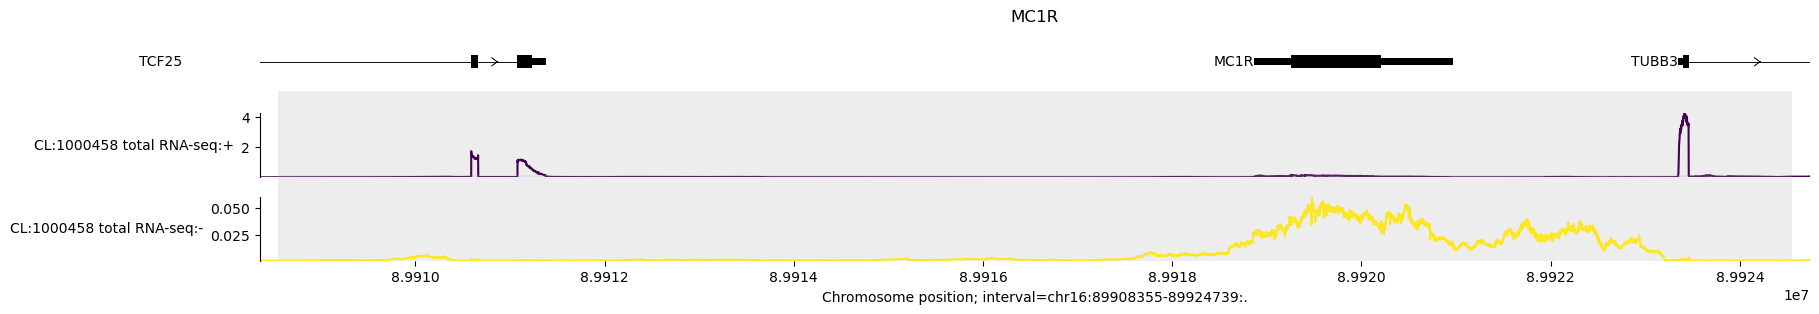

In [65]:
plot_alphagenome_view_for_gene("MC1R", dna_client.SEQUENCE_LENGTH_16KB, 16000)


# Classical Variant Effect Prediction (VEP)


In [66]:
import requests
from alphagenome.data import genome

def rsid_to_variant(rsid: str) -> genome.Variant:
    """Busca coordenadas GRCh38 de um rsID via Ensembl REST API
    e monta o objeto genome.Variant do AlphaGenome."""
    url = f"https://rest.ensembl.org/variation/human/{rsid}?content-type=application/json"
    r = requests.get(url)
    r.raise_for_status()
    data = r.json()

    # Pega o mapping na assembly GRCh38
    mapping = next(
        m for m in data["mappings"] if m["assembly_name"].startswith("GRCh38")
    )
    chrom = f"chr{mapping['seq_region_name']}"
    pos = mapping["start"]  # 1-based, igual ao que genome.Variant espera
    ref, alt = mapping["allele_string"].split("/")[:2]

    return genome.Variant(
        chromosome=chrom,
        position=pos,
        reference_bases=ref,
        alternate_bases=alt,
    )

# Exemplo de uso:
v1 = rsid_to_variant("rs10424065")
# v2 = rsid_to_variant("rs56203814")
print(v1)

chr19:3545024:C>G


In [ ]:
REF_ALT_COLORS = {'REF': 'dimgrey', 'ALT': 'red'}

def plot_alphagenome_variant_effect(
    gene: str,
    variant,
    outer_window: int = dna_client.SEQUENCE_LENGTH_500KB,
    inner_window: int = 32768,
    filter_protein_coding = True,
    filter_mane_select_transcript = True,
):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    strand = rna_features.gene_strand(gtf, gene)

    interval = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(outer_window)
    interval_32k = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(inner_window)

    gtf_transcripts = gtf
    if filter_protein_coding:
        gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
    if filter_mane_select_transcript:
        gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
    transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)
    transcripts = transcript_extractor.extract(interval)

    # Cached: this is a reference-only (no individual/haplotype) prediction, deterministic
    # for a given gene/interval/ontology, so a top-to-bottom notebook re-run reuses the
    # cache under notebooks/.cache/reference_predictions/ instead of re-spending API calls.
    ref, alt = predictions_utils.predict_variant_effect(
        client,
        gene=gene,
        interval=interval,
        variant=variant,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=[ONTOLOGY_TERMS[0]],
    )
    ref = ref.filter_to_positive_strand() if strand == '+' else ref.filter_to_negative_strand()
    alt = alt.filter_to_positive_strand() if strand == '+' else alt.filter_to_negative_strand()

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.OverlaidTracks(
                tdata={
                    'REF': ref,
                    'ALT': alt,
                },
                colors=REF_ALT_COLORS,
                ylabel_template='{biosample_name} ({strand})\n{name}',
            ),
        ],
        annotations=[
            plot_components.VariantAnnotation(
                variants=[variant]
            )
        ],
        interval=interval_32k,
        title=gene,
    )

    plt.show()      # Display this figure before creating the next one
    plt.close(fig)  # Optional: free memory

from utils import literature_variants

# Programmatically fetched, not hand-curated: every GTEx skin-tissue eQTL for MFSD12 within
# this gene's own prediction window, capped to the top `DEFAULT_TOP_N` by p-value -- see
# notebooks/utils/literature_variants.py. Uses the gtex_database skill (GTEx Portal API);
# see .licenses/gtex_database_LICENSE.txt.
variants = literature_variants.literature_variant_strings(
    "MFSD12", windows_df, ANNOTATIONS_CACHE_DIR, top_n=literature_variants.DEFAULT_TOP_N,
)
print(f"Fetched {len(variants)} GTEx skin-eQTL literature variant(s) for MFSD12 (via the gtex_database skill):")
for v in variants:
    print(" ", v)

for variant in variants:
    plot_alphagenome_variant_effect("MFSD12", genome.Variant.from_str(variant))


## Multi-modality deep dive + systematic scoring: MFSD12

This mirrors the structure of AlphaGenome's own worked example
([TAL1 in T-ALL](https://www.alphagenomedocs.com/colabs/example_analysis_workflow.html)), applied
to MFSD12 instead:

1. **Discover which ontology terms are actually available** per output type via
   `client.output_metadata()`, restricted to skin/melanocyte biosamples -- `ONTOLOGY_TERMS[0]`
   (melanocyte of skin) is known to have RNA-seq tracks (used throughout this notebook series),
   but that's not guaranteed for `DNASE`/`CHIP_HISTONE`, so this checks rather than assumes.
2. **Systematic scoring across variants**: `score_variants()` with
   `variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ']`, tidied with
   `variant_scorers.tidy_scores()` into one row per (variant, gene, biosample) -- reduces each of
   the MFSD12 literature variants above to a comparable scalar (predicted RNA-seq log2
   fold-change) across every skin/melanocyte biosample found in step 1, instead of eyeballing
   separate track plots per variant.
3. **Single-variant, multi-modality deep dive** on the top-ranked (variant, biosample) hit from
   step 2: one `predict_variant()` call requesting `RNA_SEQ`, `DNASE`, and `CHIP_HISTONE`
   together, plotted as **ALT-REF difference tracks** (`filled=True`) rather than overlaid
   REF/ALT curves -- this is what the TAL1 example does to show the full regulatory picture
   (expression *and* accessibility *and* histone marks) for one variant in one view.

None of the cells below are cached (unlike the RNA-seq-only helpers in
`notebooks/utils/predictions.py` used elsewhere in this notebook) -- they're one-off exploratory
calls across a handful of variants and biosamples, matching the AlphaGenome docs' own (uncached)
style.


In [68]:
output_metadata = client.output_metadata(organism=ORGANISM)


def _skin_melanocyte_ontology_terms(features_df) -> list[str]:
    if features_df is None or len(features_df) == 0:
        return []
    mask = (
        features_df["biosample_name"].str.contains("skin", case=False, na=False)
        | features_df["biosample_name"].str.contains("melano", case=False, na=False)
    )
    return sorted(features_df.loc[mask, "ontology_curie"].unique())


candidate_ontology_terms_by_output = {
    "RNA_SEQ": _skin_melanocyte_ontology_terms(output_metadata.rna_seq),
    "DNASE": _skin_melanocyte_ontology_terms(output_metadata.dnase),
    "CHIP_HISTONE": _skin_melanocyte_ontology_terms(output_metadata.chip_histone),
}
for output_name, terms in candidate_ontology_terms_by_output.items():
    print(f"{output_name}: {len(terms)} skin/melanocyte ontology term(s) -> {terms}")

candidate_ontology_terms = candidate_ontology_terms_by_output["RNA_SEQ"]
assert ONTOLOGY_TERMS[0] in candidate_ontology_terms, "melanocyte-of-skin RNA_SEQ track missing?"


RNA_SEQ: 10 skin/melanocyte ontology term(s) -> ['CL:0011022', 'CL:1000458', 'CL:1001606', 'CL:1001608', 'CL:2000013', 'CL:2000045', 'NTR:0000524', 'UBERON:0002097', 'UBERON:0004264', 'UBERON:0036149']
DNASE: 14 skin/melanocyte ontology term(s) -> ['CL:0011021', 'CL:0011022', 'CL:1001606', 'CL:1001608', 'CL:2000000', 'CL:2000013', 'CL:2000045', 'NTR:0000521', 'NTR:0000522', 'NTR:0000523', 'NTR:0000524', 'NTR:0000525', 'UBERON:0004264', 'UBERON:0036149']
CHIP_HISTONE: 5 skin/melanocyte ontology term(s) -> ['CL:1001606', 'CL:1001608', 'CL:2000045', 'UBERON:0001003', 'UBERON:0036149']


In [69]:
from alphagenome.models import variant_scorers

rna_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS["RNA_SEQ"]  # GeneMaskLFCScorer -> RNA-seq log2 fold-change

mfsd12_variants = [genome.Variant.from_str(v) for v in variants]  # reuse the literature variants from the VEP section above
mfsd12_intervals = [v.reference_interval.resize(dna_client.SEQUENCE_LENGTH_500KB) for v in mfsd12_variants]

mfsd12_scores_raw = client.score_variants(
    intervals=mfsd12_intervals,
    variants=mfsd12_variants,
    variant_scorers=[rna_scorer],
)

# Tidies the raw AnnData-per-variant output into one row per (variant, gene, biosample) -- same
# scoring approach the AlphaGenome docs use for TAL1.
mfsd12_scores_df = variant_scorers.tidy_scores(mfsd12_scores_raw, match_gene_strand=True)
mfsd12_scores_df = mfsd12_scores_df[
    (mfsd12_scores_df["gene_name"] == "MFSD12")
    & (mfsd12_scores_df["ontology_curie"].isin(candidate_ontology_terms))
][
    ["gene_name", "variant_id", "scored_interval", "ontology_curie", "biosample_name", "raw_score", "quantile_score"]
].sort_values("quantile_score", ascending=False).reset_index(drop=True)
mfsd12_scores_df


100%|██████████| 7/7 [00:04<00:00,  1.54it/s]


,gene_name,variant_id,scored_interval,ontology_curie,biosample_name,raw_score,quantile_score
0,MFSD12,chr19:3565255:G>A,chr19:3303111-3827399:.,UBERON:0002097,skin of body,0.016754,0.999202
1,MFSD12,chr19:3565255:G>A,chr19:3303111-3827399:.,UBERON:0036149,suprapubic skin,0.016227,0.998581
2,MFSD12,chr19:3565255:G>A,chr19:3303111-3827399:.,UBERON:0036149,suprapubic skin,0.013125,0.998376
3,MFSD12,chr19:3565255:G>A,chr19:3303111-3827399:.,UBERON:0004264,lower leg skin,0.014510,0.998262
4,MFSD12,chr19:3565255:G>A,chr19:3303111-3827399:.,UBERON:0004264,lower leg skin,0.012864,0.998202
...,...,...,...,...,...,...,...
86,MFSD12,chr19:3544894:C>A,chr19:3282750-3807038:.,UBERON:0004264,lower leg skin,-0.006422,-0.988849
87,MFSD12,chr19:3544894:C>A,chr19:3282750-3807038:.,UBERON:0002097,skin of body,-0.006881,-0.994510
88,MFSD12,chr19:3565255:G>A,chr19:3303111-3827399:.,CL:2000045,foreskin melanocyte,-0.016784,-0.998918
89,MFSD12,chr19:3565255:G>A,chr19:3303111-3827399:.,CL:1000458,melanocyte of skin,-0.016722,-0.999087


Deep-diving on the top-ranked hit: chr19:3565255:G>A in skin of body (UBERON:0002097)
No DNASE tracks available for UBERON:0002097 -- skipping.
No CHIP_HISTONE tracks available for UBERON:0002097 -- skipping.


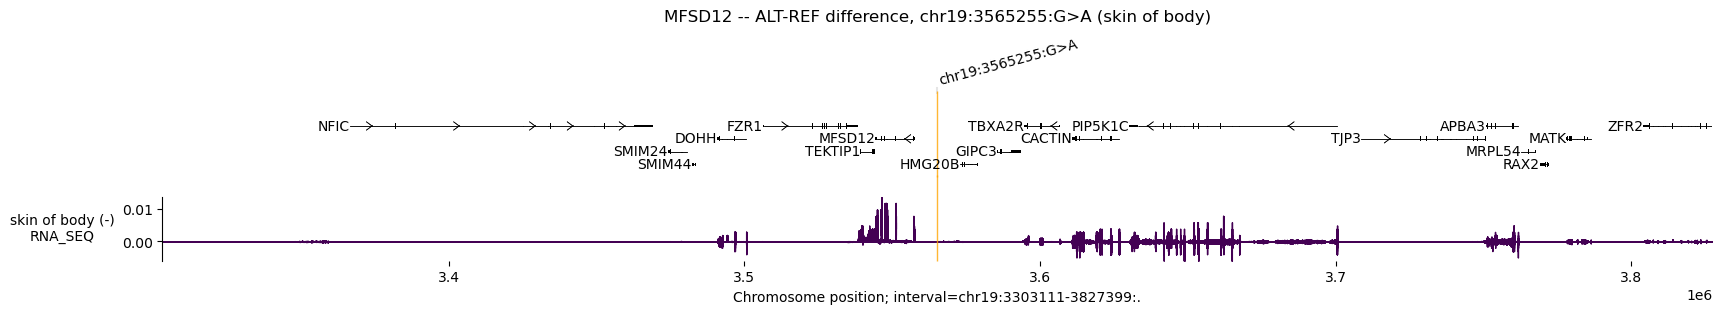

In [70]:
top_row = mfsd12_scores_df.iloc[0]
print(f"Deep-diving on the top-ranked hit: {top_row['variant_id']} in {top_row['biosample_name']} ({top_row['ontology_curie']})")

deepdive_output = client.predict_variant(
    interval=top_row["scored_interval"],
    variant=top_row["variant_id"],
    requested_outputs=[
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.CHIP_HISTONE,
    ],
    ontology_terms=[top_row["ontology_curie"]],
)

mfsd12_strand = rna_features.gene_strand(gtf, "MFSD12")


def _diff_track(ref_track, alt_track, strand):
    ref = ref_track.filter_to_positive_strand() if strand == '+' else ref_track.filter_to_negative_strand()
    alt = alt_track.filter_to_positive_strand() if strand == '+' else alt_track.filter_to_negative_strand()
    return alt - ref


gtf_transcripts_mane = gene_annotation.filter_to_mane_select_transcript(gene_annotation.filter_protein_coding(gtf))
transcripts_deepdive = transcript_utils.TranscriptExtractor(gtf_transcripts_mane).extract(top_row["scored_interval"])

track_components = []
for output_name, ref_track, alt_track in [
    ("RNA_SEQ", deepdive_output.reference.rna_seq, deepdive_output.alternate.rna_seq),
    ("DNASE", deepdive_output.reference.dnase, deepdive_output.alternate.dnase),
    ("CHIP_HISTONE", deepdive_output.reference.chip_histone, deepdive_output.alternate.chip_histone),
]:
    if ref_track is None or len(ref_track.metadata) == 0:
        print(f"No {output_name} tracks available for {top_row['ontology_curie']} -- skipping.")
        continue
    track_components.append(
        plot_components.Tracks(
            tdata=_diff_track(ref_track, alt_track, mfsd12_strand),
            ylabel_template='{biosample_name} ({strand})\n' + output_name,
            filled=True,
        )
    )

fig = plot_components.plot(
    [plot_components.TranscriptAnnotation(transcripts_deepdive)] + track_components,
    annotations=[plot_components.VariantAnnotation([top_row["variant_id"]])],
    interval=top_row["scored_interval"],
    title=f"MFSD12 -- ALT-REF difference, {top_row['variant_id']} ({top_row['biosample_name']})",
)
plt.show()
plt.close(fig)


### Are these literature variants special, or would any common variant in this region look similar?

This ports the last piece of the TAL1 example: comparing the disease/literature-associated
variants against **background** variants, to see whether the curated alleles stand out from
generic real-world variation.

The background set here is **real 1000 Genomes variants, not synthetic substitutions**: every
biallelic SNV in MFSD12's already-bundled 1000 Genomes VCF (`notebooks/data/variants/MFSD12.vcf.gz`
-- the same file this notebook series already uses to build individual consensus sequences) with
at least `BACKGROUND_MIN_ALLELE_FREQUENCY` allele frequency in the panel, excluding the 4 curated
literature positions, then a reproducible random sample of `N_BACKGROUND_VARIANTS` of them. This
is a closer match to the *spirit* of the TAL1 example (comparing real variants against a
plausible background) than inventing hypothetical substitutions.

One consequence of sampling real variants across the whole gene window instead of only at the
literature positions: background and literature variants no longer share positions, so this
version compares the two groups as a whole (one rain + density plot) rather than faceting
per-position.


In [ ]:
from utils import data as data_utils

BACKGROUND_MIN_ALLELE_FREQUENCY = 0.01  # "common" variant threshold: >=1% allele frequency in the 1000 Genomes panel
N_BACKGROUND_VARIANTS = 30

_, mfsd12_vcf_path = data_utils.gene_paths("MFSD12")
literature_positions = {v.position for v in mfsd12_variants}
background_variants = data_utils.sample_background_variants_from_vcf(
    mfsd12_vcf_path,
    exclude_positions=literature_positions,
    min_allele_frequency=BACKGROUND_MIN_ALLELE_FREQUENCY,
    n=N_BACKGROUND_VARIANTS,
)
print(
    f"Sampled {len(background_variants)} real 1000 Genomes background SNV(s) "
    f"(AF >= {BACKGROUND_MIN_ALLELE_FREQUENCY}) from MFSD12's window, excluding the "
    f"{len(literature_positions)} curated literature position(s)."
)

# Literature-variant scores are already computed (mfsd12_scores_df) -- reuse them, restricted to
# the single melanocyte-of-skin ontology for a clean one-biosample comparison, and only score the
# new background variants fresh (no redundant API calls for the 7 literature variants).
literature_slice = mfsd12_scores_df[mfsd12_scores_df["ontology_curie"] == ONTOLOGY_TERMS[0]].copy()
literature_slice["is_literature_variant"] = True

background_intervals = [v.reference_interval.resize(dna_client.SEQUENCE_LENGTH_500KB) for v in background_variants]
background_scores_raw = client.score_variants(
    intervals=background_intervals,
    variants=background_variants,
    variant_scorers=[rna_scorer],
    max_workers=2,
)
background_slice = variant_scorers.tidy_scores(background_scores_raw, match_gene_strand=True)
background_slice = background_slice[
    (background_slice["gene_name"] == "MFSD12") & (background_slice["ontology_curie"] == ONTOLOGY_TERMS[0])
].copy()
background_slice["is_literature_variant"] = False

comparison_df = pd.concat([literature_slice, background_slice], ignore_index=True)
comparison_df["position"] = comparison_df["variant_id"].map(lambda v: v.position)
comparison_df


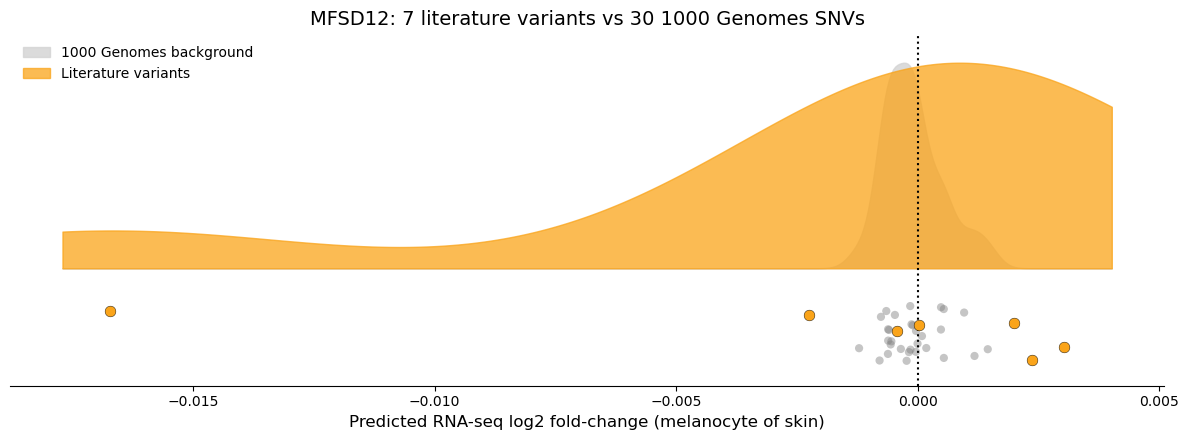

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------------------------------------------------------------------
# Dados
# ---------------------------------------------------------------------

background = comparison_df.loc[
    ~comparison_df["is_literature_variant"],
    "raw_score"
].to_numpy()

literature = comparison_df.loc[
    comparison_df["is_literature_variant"],
    "raw_score"
].to_numpy()

xmin = min(background.min(), literature.min())
xmax = max(background.max(), literature.max())

pad = (xmax - xmin) * 0.05
xmin -= pad
xmax += pad

x = np.linspace(xmin, xmax, 500)

# ---------------------------------------------------------------------
# KDE
# ---------------------------------------------------------------------

kde_background = gaussian_kde(background, bw_method=0.4)
kde_literature = gaussian_kde(literature, bw_method=0.6)

y_bg = kde_background(x)
y_lit = kde_literature(x)

# Normaliza apenas para fins visuais
height = 0.35
y_bg = y_bg / y_bg.max() * height
y_lit = y_lit / y_lit.max() * height

# ---------------------------------------------------------------------
# Figura
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 4.5))

# Background density
ax.fill_between(
    x,
    0,
    y_bg,
    color="lightgray",
    alpha=0.8,
    label="1000 Genomes background",
)

# Literature density
ax.fill_between(
    x,
    0,
    y_lit,
    color="#FAA41A",
    alpha=0.75,
    label="Literature variants",
)

# ---------------------------------------------------------------------
# Rain
# ---------------------------------------------------------------------

rng = np.random.default_rng(42)

bg_y = -0.06 - rng.random(len(background)) * 0.10
lit_y = -0.06 - rng.random(len(literature)) * 0.10

ax.scatter(
    background,
    bg_y,
    s=35,
    color="gray",
    alpha=0.45,
    edgecolor="none",
)

ax.scatter(
    literature,
    lit_y,
    s=60,
    color="#FAA41A",
    edgecolor="black",
    linewidth=0.3,
    zorder=5,
)

# ---------------------------------------------------------------------
# Linha em zero
# ---------------------------------------------------------------------

ax.axvline(
    0,
    color="black",
    linestyle=":",
    linewidth=1.5,
)

# ---------------------------------------------------------------------
# Aparência
# ---------------------------------------------------------------------

ax.set_ylim(-0.20, height + 0.05)
ax.set_yticks([])

ax.set_xlabel(
    "Predicted RNA-seq log2 fold-change (melanocyte of skin)",
    fontsize=12,
)

ax.set_title(
    f"MFSD12: {len(literature)} literature variants vs "
    f"{len(background)} 1000 Genomes SNVs",
    fontsize=14,
)

ax.legend(frameon=False)

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

### Do the MFSD12 SNPs contribute together? (haplotype workaround)

AlphaGenome scores one variant at a time -- it has no native notion of "predict the joint effect
of these N variants together." The AlphaGenome docs work around this with a
[haplotype trick](https://www.alphagenomedocs.com/colabs/haplotype_workaround.html): fetch the
reference sequence spanning every mutation, apply all of the alternate alleles to it at once, and
score that as a single combined `genome.Variant` -- then compare the combined prediction against
the reference and against each mutation predicted alone, to see whether the combination looks
more than the sum of its parts.

The scoring above shows the 7 literature variants split by **direction**: most have a sizeable
predicted effect, but some push RNA-seq signal up and others push it down. Mixing signs into one
haplotype would muddy the question -- a positive and a negative variant partly cancelling out
looks the same as "no cooperative effect" whether or not either individually matters. So this
builds **two** haplotypes instead of one: every literature variant with a **positive** predicted
effect combined together, and every literature variant with a **negative** predicted effect
combined together, each checked separately for whether the combination looks like more (or less)
than the sum of its parts.

Adaptations for MFSD12:
- **Reference sequence source**: the docs fetch hg38 fresh from a GCS FASTA. This notebook
  already has MFSD12's window cached locally (`notebooks/data/references/MFSD12/ref.window.fa`,
  from `prepare_data.ipynb`), so `create_haplotype()` below reads from there instead -- no new
  network dependency, consistent with this notebook staying self-contained.
- **Picking one variant per position, per direction**: a haplotype needs exactly one allele per
  position, but 3 of MFSD12's 4 curated positions have more than one literature-reported
  alternate allele (`chr19:3544894` has all 3 possible substitutions curated). Within each
  direction (positive/negative), the **representative allele per position** is picked as
  whichever curated variant of that direction had the largest `|predicted effect|`
  (melanocyte-of-skin RNA-seq) -- a data-driven choice, not an arbitrary one. A position whose
  literature alleles span both directions contributes a (different) representative allele to
  *both* haplotypes.
- **1MB range check**: MFSD12's 4 positions span `chr19:3544894-3565601`, ~20.7kb -- comfortably
  under the docs' 1MB haplotype limit, for either haplotype.
- **Modality**: the docs use `RNA_SEQ` + `ATAC`. This uses `RNA_SEQ` + `DNASE` instead, since
  `DNASE` (not `ATAC`) is what this notebook already validated has skin/melanocyte tracks
  earlier in this section -- both serve the same "chromatin accessibility" role.

Like the docs, this is a **visual/descriptive** comparison, not a statistical test for
cooperativity -- the summary table at the end reports `combined - sum(individual deltas)` per
direction as one simple numeric hint (super-additive vs. sub-additive-looking), which the docs
don't compute but is a natural extension given the question being asked here ("do they
contribute together").


In [73]:
def create_haplotype(mutations: list, window_start: int, window_seq: str) -> dict:
    """Builds one combined genome.Variant spanning every mutation's position, with all
    alternate alleles applied at once -- the same workaround the AlphaGenome docs use, but
    reading the reference sequence from this notebook's cached gene-window FASTA instead of
    a fresh download. `window_start` must be the 0-based start of the window `window_seq` was
    read from (e.g. windows_df's gene window), consistent with how `gene_rows`/`windows_df`
    positions line up with notebooks/data/references/<gene>/ref.window.fa on disk."""
    if not mutations:
        raise ValueError("mutations must be non-empty")
    chrom = mutations[0].chromosome
    if any(m.chromosome != chrom for m in mutations):
        raise ValueError("all mutations must be on the same chromosome")

    positions = [m.position for m in mutations]
    min_pos, max_pos = min(positions), max(positions)
    if max_pos - min_pos > 1_000_000:
        raise ValueError(f"mutations span {max_pos - min_pos:,} bp, exceeding the 1MB haplotype limit")

    lo = min_pos - window_start
    hi = max_pos - window_start + 1
    ref_span = window_seq[lo:hi]

    ref_list = list(ref_span)
    alt_list = list(ref_span)
    for m in mutations:
        rel = m.position - min_pos
        assert ref_list[rel].upper() == m.reference_bases.upper(), (
            f"reference mismatch at {m}: window has {ref_list[rel]!r}, variant expects {m.reference_bases!r}"
        )
        alt_list[rel] = m.alternate_bases

    combined_variant = genome.Variant(
        chromosome=chrom,
        position=min_pos,
        reference_bases="".join(ref_list),
        alternate_bases="".join(alt_list),
    )
    return {
        "combined_variant": combined_variant,
        "individual_variants": {m.position: m for m in mutations},
    }


# Split literature variants by the *direction* of their predicted effect (melanocyte-of-skin
# RNA-seq log2 fold-change), then pick one representative allele per position *within each
# direction* (largest |effect|) -- a haplotype can only carry one allele per position, but a
# position with literature alleles of both directions can still contribute to both haplotypes.
literature_only = comparison_df[comparison_df["is_literature_variant"]].copy()
literature_only["direction"] = np.where(literature_only["raw_score"] > 0, "positive", "negative")

representative_by_direction = {}
for direction, group in literature_only.groupby("direction"):
    rows = (
        group.assign(abs_score=group["raw_score"].abs())
        .sort_values("abs_score", ascending=False)
        .drop_duplicates(subset="position", keep="first")
        .sort_values("position")
    )
    representative_by_direction[direction] = rows
    print(f"{direction} ({len(rows)} representative variant(s), largest |predicted effect| per position):")
    print(rows[["variant_id", "position", "raw_score"]].to_string(index=False))
    print()


negative (3 representative variant(s), largest |predicted effect| per position):
       variant_id  position  raw_score
chr19:3544894:C>A   3544894  -0.002250
chr19:3565255:G>A   3565255  -0.016722
chr19:3565601:T>C   3565601  -0.000422

positive (2 representative variant(s), largest |predicted effect| per position):
       variant_id  position  raw_score
chr19:3544894:C>T   3544894   0.002373
chr19:3545024:C>G   3545024   0.003033



In [74]:
from utils import data as data_utils

ref_fa, _ = data_utils.gene_paths("MFSD12")


def _read_fasta_sequence(path) -> str:
    with open(path) as f:
        return "".join(line.strip() for line in f if not line.startswith(">"))


mfsd12_ref_window_seq = _read_fasta_sequence(ref_fa)
mfsd12_ref_window_start = int(gene_rows["MFSD12"]["start"])

mfsd12_haplotypes = {}
for direction, rows in representative_by_direction.items():
    representative_variants = rows["variant_id"].tolist()
    haplotype = create_haplotype(representative_variants, mfsd12_ref_window_start, mfsd12_ref_window_seq)
    mfsd12_haplotypes[direction] = haplotype

    combined = haplotype["combined_variant"]
    print(
        f"[{direction}] combined haplotype: {combined.chromosome}:{combined.position}-"
        f"{combined.position + len(combined.reference_bases) - 1} "
        f"({len(haplotype['individual_variants'])} variants combined)"
    )
    for pos, var in sorted(haplotype["individual_variants"].items()):
        print(f"    {var}")


[negative] combined haplotype: chr19:3544894-3565601 (3 variants combined)
    chr19:3544894:C>A
    chr19:3565255:G>A
    chr19:3565601:T>C
[positive] combined haplotype: chr19:3544894-3545024 (2 variants combined)
    chr19:3544894:C>T
    chr19:3545024:C>G


In [75]:
haplotype_requested_outputs = [dna_client.OutputType.RNA_SEQ, dna_client.OutputType.DNASE]

# Combined haplotype + each representative variant alone, all on the identical interval/ontology
# so the comparison below is apples-to-apples (same as the docs' shared prediction_params) --
# done separately (own interval, own predictions) for the positive-direction and
# negative-direction haplotypes.
mfsd12_haplotype_intervals = {}
mfsd12_haplotype_predictions = {}
for direction, haplotype in mfsd12_haplotypes.items():
    combined = haplotype["combined_variant"]
    interval = combined.reference_interval.resize(dna_client.SEQUENCE_LENGTH_100KB)
    mfsd12_haplotype_intervals[direction] = interval

    predictions = {
        "combined": client.predict_variant(
            interval=interval,
            variant=combined,
            requested_outputs=haplotype_requested_outputs,
            ontology_terms=[ONTOLOGY_TERMS[0]],
        ),
    }
    for pos, var in haplotype["individual_variants"].items():
        predictions[pos] = client.predict_variant(
            interval=interval,
            variant=var,
            requested_outputs=haplotype_requested_outputs,
            ontology_terms=[ONTOLOGY_TERMS[0]],
        )
    mfsd12_haplotype_predictions[direction] = predictions

    print(
        f"[{direction}] predicted the combined haplotype + {len(haplotype['individual_variants'])} "
        f"individual variants, all on {interval}."
    )


[negative] predicted the combined haplotype + 3 individual variants, all on chr19:3489711-3620783:..
[positive] predicted the combined haplotype + 2 individual variants, all on chr19:3479423-3610495:..


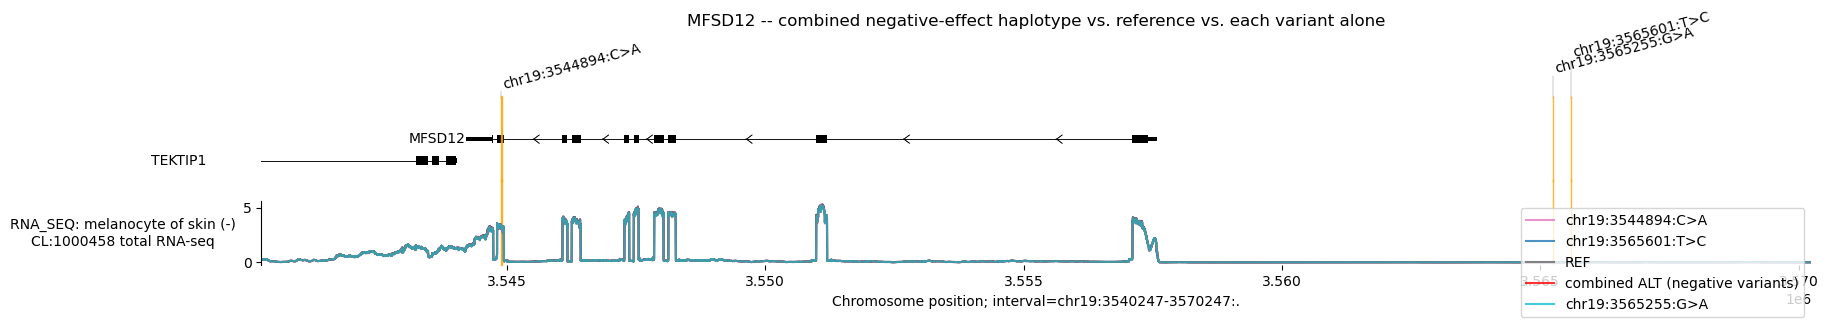

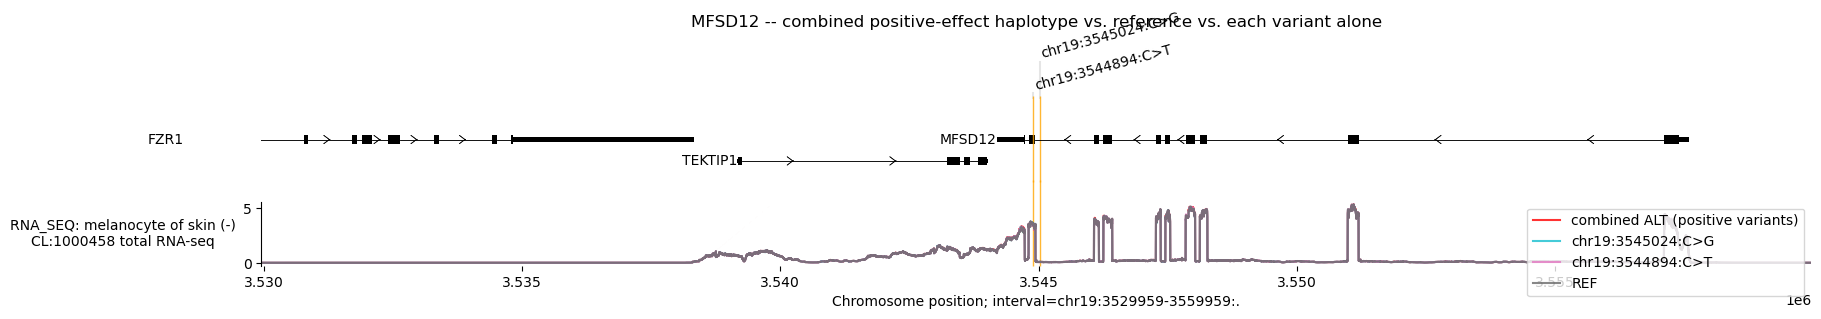

In [76]:
PALETTE = ["#e377c2", "#17becf", "#1f77b4", "#2ca02c", "#9467bd", "#8c564b"]


def _strand_filter(track):
    return track.filter_to_positive_strand() if mfsd12_strand == "+" else track.filter_to_negative_strand()


def plot_haplotype_overlay(direction: str) -> None:
    haplotype = mfsd12_haplotypes[direction]
    predictions = mfsd12_haplotype_predictions[direction]
    interval = mfsd12_haplotype_intervals[direction]
    combined_label = f"combined ALT ({direction} variants)"

    colors = {"REF": "dimgrey", combined_label: "red"}
    tdata_rna = {
        "REF": _strand_filter(predictions["combined"].reference.rna_seq),
        combined_label: _strand_filter(predictions["combined"].alternate.rna_seq),
    }
    tdata_dnase = {
        "REF": _strand_filter(predictions["combined"].reference.dnase),
        combined_label: _strand_filter(predictions["combined"].alternate.dnase),
    }

    annotations_list = []
    for (pos, var), color in zip(sorted(haplotype["individual_variants"].items()), PALETTE):
        label = str(var)
        tdata_rna[label] = _strand_filter(predictions[pos].alternate.rna_seq)
        tdata_dnase[label] = _strand_filter(predictions[pos].alternate.dnase)
        colors[label] = color
        annotations_list.append(plot_components.VariantAnnotation([var], alpha=0.8))

    transcripts_haplotype = transcript_utils.TranscriptExtractor(gtf_transcripts_mane).extract(interval)

    fig = plot_components.plot(
        [
            plot_components.TranscriptAnnotation(transcripts_haplotype),
            plot_components.OverlaidTracks(
                tdata=tdata_rna, colors=colors, ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}"
            ),
            plot_components.OverlaidTracks(
                tdata=tdata_dnase, colors=colors, ylabel_template="DNASE: {biosample_name}\n{name}"
            ),
        ],
        interval=interval.resize(30000),
        annotations=annotations_list,
        title=f"MFSD12 -- combined {direction}-effect haplotype vs. reference vs. each variant alone",
    )
    plt.show()
    plt.close(fig)


for direction in mfsd12_haplotypes:
    plot_haplotype_overlay(direction)


In [77]:
def _signal_sum(track) -> float:
    return float(_strand_filter(track).values.sum())


def haplotype_summary(direction: str) -> pd.DataFrame:
    haplotype = mfsd12_haplotypes[direction]
    predictions = mfsd12_haplotype_predictions[direction]

    individual_deltas = {
        pos: _signal_sum(predictions[pos].alternate.rna_seq) - _signal_sum(predictions[pos].reference.rna_seq)
        for pos in haplotype["individual_variants"]
    }
    combined_delta = (
        _signal_sum(predictions["combined"].alternate.rna_seq)
        - _signal_sum(predictions["combined"].reference.rna_seq)
    )
    sum_of_individual_deltas = sum(individual_deltas.values())

    rows = [
        {"direction": direction, "variant": str(haplotype["individual_variants"][pos]), "rna_seq_signal_delta": delta}
        for pos, delta in individual_deltas.items()
    ] + [
        {"direction": direction, "variant": "SUM of the individual deltas", "rna_seq_signal_delta": sum_of_individual_deltas},
        {"direction": direction, "variant": f"combined haplotype ({direction} variants together)", "rna_seq_signal_delta": combined_delta},
    ]

    diff = combined_delta - sum_of_individual_deltas
    looks_like = "super-additive / cooperative-looking" if abs(combined_delta) > abs(sum_of_individual_deltas) else "sub-additive / redundant-looking"
    print(f"[{direction}] combined - sum(individual deltas) = {diff:+.4f}  ({looks_like})")
    return pd.DataFrame(rows)


haplotype_summary_df = pd.concat(
    [haplotype_summary(direction) for direction in mfsd12_haplotypes], ignore_index=True
)
print("\nDescriptive comparison only -- not a statistical test, same caveat the AlphaGenome docs give.")
haplotype_summary_df


[negative] combined - sum(individual deltas) = -27.9365  (super-additive / cooperative-looking)
[positive] combined - sum(individual deltas) = +9.6162  (super-additive / cooperative-looking)

Descriptive comparison only -- not a statistical test, same caveat the AlphaGenome docs give.


,direction,variant,rna_seq_signal_delta
0,negative,chr19:3544894:C>A,28.505859
1,negative,chr19:3565255:G>A,-260.963867
2,negative,chr19:3565601:T>C,2.969727
3,negative,SUM of the individual deltas,-229.488281
4,negative,combined haplotype (negative variants together),-257.424805
5,positive,chr19:3544894:C>T,48.917969
6,positive,chr19:3545024:C>G,52.254883
7,positive,SUM of the individual deltas,101.172852
8,positive,combined haplotype (positive variants together),110.789062
